# K-Nearest Neighbors (KNN) Classification

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## 2. Load and Explore the Iris Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: [sepal_length, sepal_width, petal_length, petal_width]
y = iris.target  # Target: species (0, 1, 2)

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# Display basic information
print("Dataset shape:", X.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nTarget distribution:")
print(df['species'].value_counts())

Dataset shape: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (

## 3. Split Data and Normalize Features

Feature normalization is important for KNN because it's a distance-based algorithm.

In [3]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Testing set size:", X_test_scaled.shape)
print("\nScaled training data (first 3 samples):")
print(X_train_scaled[:3])

Training set size: (120, 4)
Testing set size: (30, 4)

Scaled training data (first 3 samples):
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]]


## 4. Train KNN Models with Different K Values

In [4]:
# Test different K values
k_values = [1, 3, 5, 7, 9, 11, 15]
train_accuracies = []
test_accuracies = []

for k in k_values:
    # Create and train the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"K={k:2d} | Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

# Find the best K
best_k_idx = np.argmax(test_accuracies)
best_k = k_values[best_k_idx]
print(f"\nBest K value: {best_k} with test accuracy: {test_accuracies[best_k_idx]:.4f}")

K= 1 | Train Accuracy: 1.0000 | Test Accuracy: 0.9667
K= 3 | Train Accuracy: 0.9583 | Test Accuracy: 0.9333
K= 5 | Train Accuracy: 0.9750 | Test Accuracy: 0.9333
K= 7 | Train Accuracy: 0.9750 | Test Accuracy: 0.9667
K= 9 | Train Accuracy: 0.9583 | Test Accuracy: 0.9667
K=11 | Train Accuracy: 0.9583 | Test Accuracy: 0.9667
K=15 | Train Accuracy: 0.9667 | Test Accuracy: 0.9667

Best K value: 1 with test accuracy: 0.9667


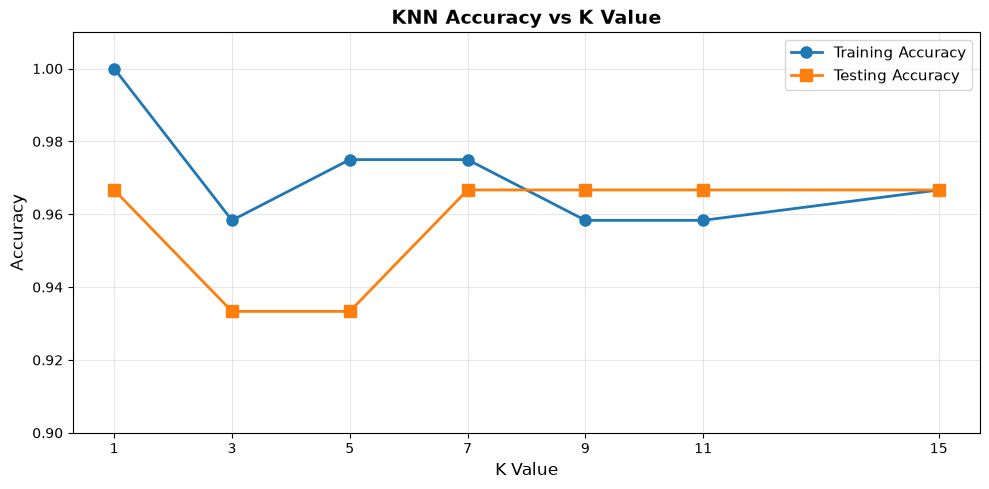

In [9]:
# Plot accuracies for different K values
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(k_values, test_accuracies, 's-', label='Testing Accuracy', linewidth=2, markersize=8)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0.9, 1.01])
plt.tight_layout()
plt.savefig('knn_accuracy_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Detailed Model Evaluation with Best K

In [6]:
# Train the best model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Make predictions on test set
y_test_pred_best = best_knn.predict(X_test_scaled)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred_best)
print(f"Test Accuracy with K={best_k}: {test_accuracy:.4f}\n")

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred_best, 
                          target_names=iris.target_names))

Test Accuracy with K=1: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 6. Confusion Matrix Visualization

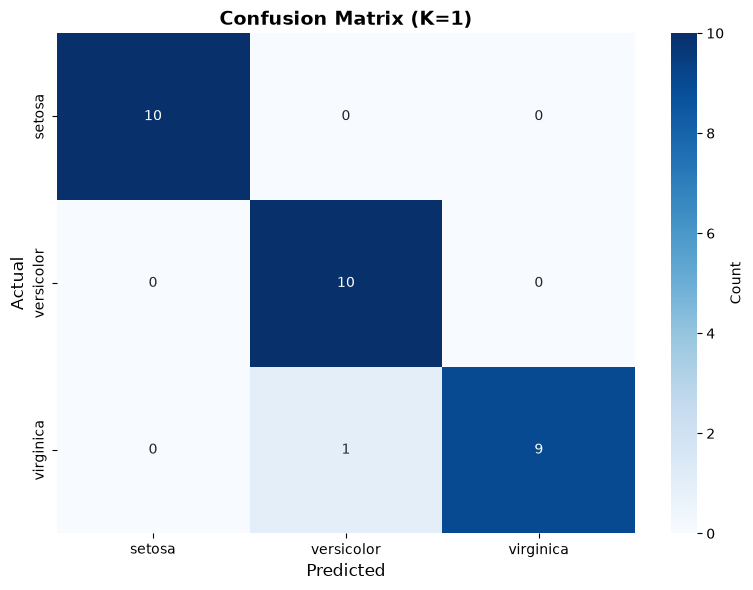

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [10]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred_best)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (K={best_k})', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion Matrix:")
print(cm)

## 7. Decision Boundaries Visualization

We'll visualize the decision boundaries using the first two features (sepal length and sepal width).

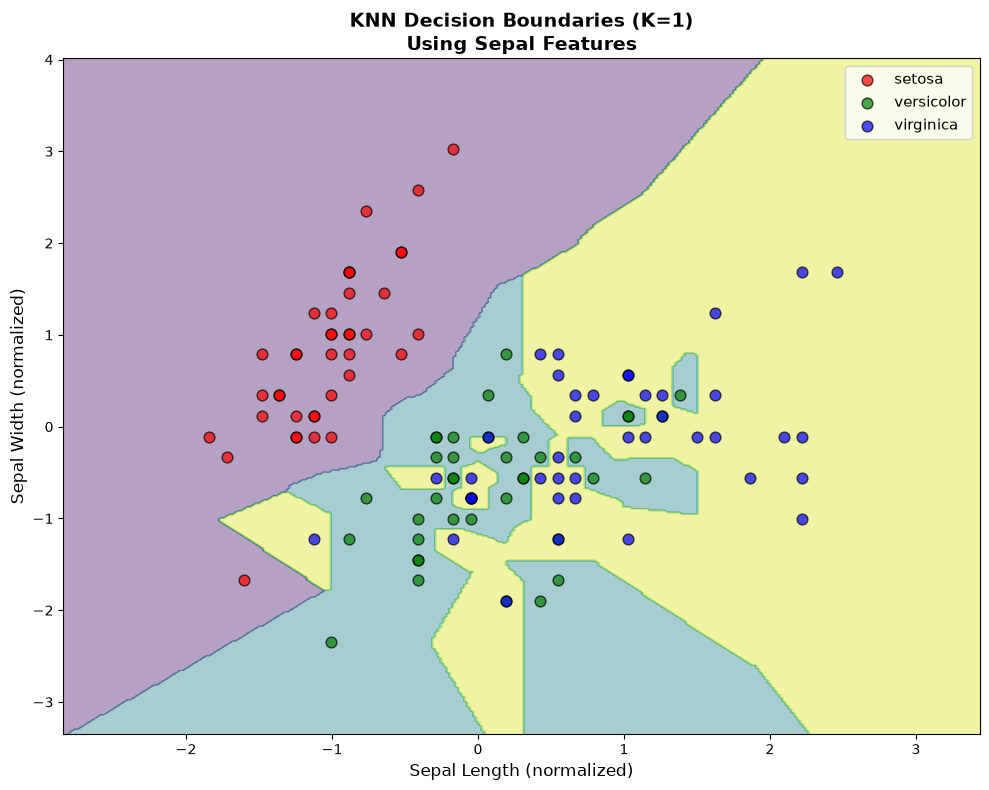

In [11]:
# Use only first two features for 2D visualization
X_train_2d = X_train_scaled[:, :2]  # sepal length and sepal width
X_test_2d = X_test_scaled[:, :2]

# Train KNN model with 2D features
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train)

# Create a mesh to plot decision boundaries
h = 0.02  # step size in the mesh
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

# Plot training points
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    idx = y_train == i
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], 
               c=color, label=iris.target_names[i], 
               edgecolors='k', s=60, alpha=0.7)

plt.xlabel('Sepal Length (normalized)', fontsize=12)
plt.ylabel('Sepal Width (normalized)', fontsize=12)
plt.title(f'KNN Decision Boundaries (K={best_k})\nUsing Sepal Features', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()